In [ ]:
import urllib.request
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy
from astropy.table import Table
import sunpy.map
import sunpy.coordinates
from astropy.coordinates import SkyCoord
import sunpy.visualization.colormaps


In [ ]:
# UNCOMMENT and then comment back
# #  Create a dedicated folder on your computer to hold the files
# folder_name = "rhessi_cycle24_fits"
# os.makedirs(folder_name, exist_ok=True)

# print("Starting bulk download from NASA dbase...")

# # Loop through the years (2008 to 2018)
# for year in range(2008, 2019):
#     # Loop through the months (1 to 12)
#     for month in range(1, 13):
        
#         # Skip everything in 2008 before December
#         if year == 2008 and month < 12:
#             continue
            
#         # Stop trying to download after RHESSI died in August 2018
#         if year == 2018 and month > 8:
#             break

#         # Format the numbers to match NASA's exact filenames (e.g., 200812)
#         month_str = f"{month:02d}"
#         filename = f"hessi_flare_list_{year}{month_str}.fits"
        
#         # Build the exact dbase URL
#         url = f"https://hesperia.gsfc.nasa.gov/hessidata/dbase/{filename}"
#         save_path = os.path.join(folder_name, filename)

#         print(f"Fetching {filename}...")
        
#         #  Download the file! If NASA's server is missing a month, it skips it.
#         try:
#             urllib.request.urlretrieve(url, save_path)
#         except Exception:
#             print(f"  -> Skipping {filename} (File missing on NASA server)")

# print("Download complete! All .fits files are in your folder.")

In [ ]:
# folder_name = "rhessi_cycle24_fits"
# monthly_dataframes = []

# print("Cracking open FITS files (bypassing FLAG_IDS)...")

# for filename in os.listdir(folder_name):
#     if filename.endswith(".fits"):
#         file_path = os.path.join(folder_name, filename)
        
#         try:
#             # Open HDU 3
#             fits_table = Table.read(file_path, format='fits', hdu=3)
            
#             #  Tell Python to only keep columns that are 1D (standard single numbers)
#             # This automatically drops the  FLAG_IDS column
#             clean_columns = [name for name in fits_table.colnames if len(fits_table[name].shape) <= 1]
            
#             # Convert only the clean columns to Pandas
#             df = fits_table[clean_columns].to_pandas()
#             monthly_dataframes.append(df)
            
#         except Exception as e:
#             print(f"Could not read {filename}: {e}")

# # Combine
# master_df = pd.concat(monthly_dataframes, ignore_index=True)

# print("\n--- EXTRACTION COMPLETE ---")
# print(f"Total flares loaded: {len(master_df)}")

# print("\nHere are the exact columns we have to work with:")
# print(master_df.columns.tolist())

Cracking open FITS files (bypassing FLAG_IDS)...

--- EXTRACTION COMPLETE ---
Total flares loaded: 59786

Here are the exact columns we have to work with:
['ID_NUMBER', 'START_TIME', 'END_TIME', 'PEAK_TIME', 'PEAK_COUNTRATE', 'BCK_COUNTRATE', 'TOTAL_COUNTS', 'PEAK_CORRECTION', 'TOTAL_CORRECTION', 'FILENAME', 'SFLAG1', 'ACTIVE_REGION', 'GOES_CLASS', 'RADIAL_OFFSET', 'PEAK_PHFLUX', 'TOT_PHFLUENCE', 'E_PHFLUENCE', 'PEAK_PHFLUX_SIGMA', 'TOT_PHFLUENCE_SIGMA', 'E_PHFLUENCE_SIGMA', 'ALT_ID']


In [ ]:

# #  open  one file to look at the raw FITS table
# test_table = Table.read("rhessi_cycle24_fits/hessi_flare_list_201109.fits", format='fits', hdu=3)

# print("RAW NASA COLUMNS:")
# print(test_table.colnames)

RAW NASA COLUMNS:
['ID_NUMBER', 'START_TIME', 'END_TIME', 'PEAK_TIME', 'BCK_TIME', 'IMAGE_TIME', 'ENERGY_RANGE_FOUND', 'ENERGY_HI', 'PEAK_COUNTRATE', 'BCK_COUNTRATE', 'TOTAL_COUNTS', 'PEAK_CORRECTION', 'TOTAL_CORRECTION', 'POSITION', 'SPIN_AXIS', 'FSPOS', 'FILENAME', 'FLAGS', 'SEG_INDEX_MASK', 'EXTRA_BCK', 'SFLAG1', 'ACTIVE_REGION', 'GOES_CLASS', 'RADIAL_OFFSET', 'PEAK_PHFLUX', 'TOT_PHFLUENCE', 'E_PHFLUENCE', 'PEAK_PHFLUX_SIGMA', 'TOT_PHFLUENCE_SIGMA', 'E_PHFLUENCE_SIGMA', 'GOES_LEVEL_PK', 'ALT_ID']


In [2]:

folder_name = "rhessi_cycle24_fits"
monthly_dataframes = []

print("Extracting full 10-year dataset (splitting POSITION into X/Y)...")

for filename in os.listdir(folder_name):
    if filename.endswith(".fits"):
        file_path = os.path.join(folder_name, filename)
        
        try:
            # Open HDU 3
            fits_table = Table.read(file_path, format='fits', hdu=3)
            
            
            # Slice the 2D POSITION array into two separate 1D columns
            fits_table['posi_x'] = fits_table['POSITION'][:, 0]
            fits_table['posi_y'] = fits_table['POSITION'][:, 1]
            
            # Keep the clean 1D columns 
            clean_columns = [name for name in fits_table.colnames if len(fits_table[name].shape) <= 1]
            
            # Convert to Pandas
            df = fits_table[clean_columns].to_pandas()
            monthly_dataframes.append(df)
            
        except Exception as e:
            # Don't print every single skipped file
            pass

# Combine
master_df = pd.concat(monthly_dataframes, ignore_index=True)

print("\n--- EXTRACTION COMPLETE ---")
print(f"Total flares loaded: {len(master_df)}")

print("\nFinal variables ready for analysis:")
columns_check = ['START_TIME', 'posi_x', 'posi_y', 'TOTAL_COUNTS']
print(master_df[columns_check].head())

Extracting full 10-year dataset (splitting POSITION into X/Y)...

--- EXTRACTION COMPLETE ---
Total flares loaded: 59786

Final variables ready for analysis:
    START_TIME      posi_x      posi_y  TOTAL_COUNTS
0  944130040.0    0.000000    0.000000      236956.0
1  944168404.0 -634.993896  257.611176      124864.0
2  944194280.0    0.000000    0.000000       82409.0
3  944227920.0    0.000000    0.000000      204578.0
4  944260488.0 -199.096191  137.927261       86420.0


Usable flares for spatial analysis: 57793


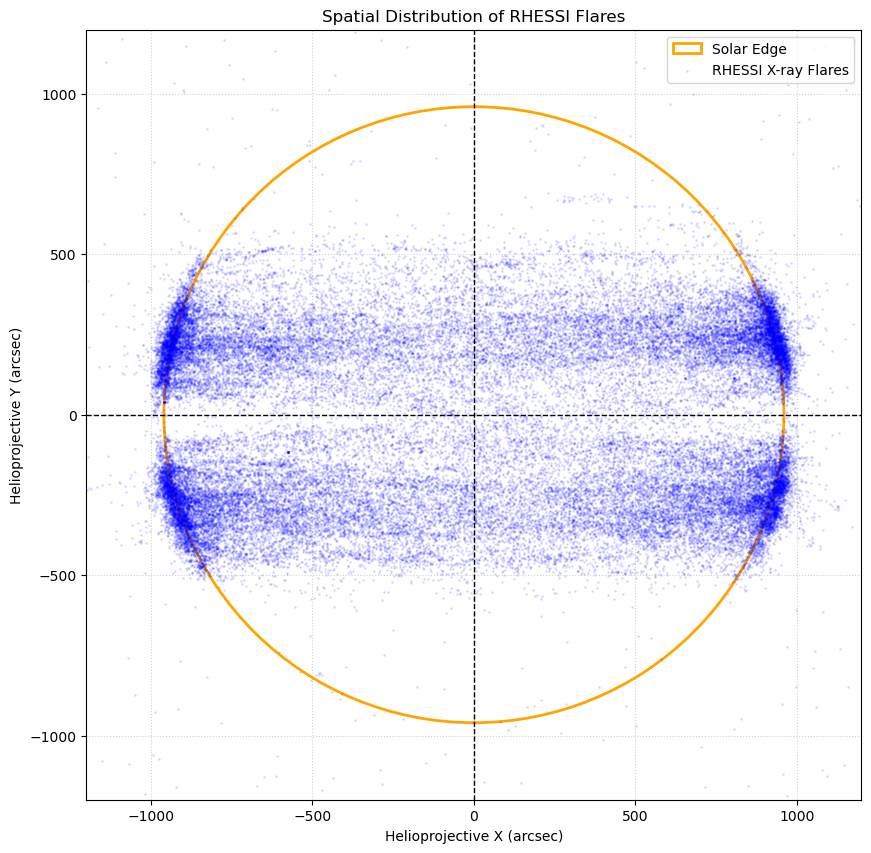

In [3]:

#  Keep only the flares where X and Y are NOT exactly zero
clean_df = master_df[(master_df['posi_x'] != 0.0) & (master_df['posi_y'] != 0.0)].copy()

# Let's see how many usable flares survived 
print(f"Usable flares for spatial analysis: {len(clean_df)}")

#  The Spatial Map
plt.figure(figsize=(10, 10))

# Draw the boundary of the Sun (The solar disk is roughly 960 arcseconds in radius)
sun_circle = plt.Circle((0, 0), 960, color='orange', fill=False, linewidth=2, label='Solar Edge')
plt.gca().add_patch(sun_circle)

# Plot all the RHESSI coordinates
# (Used s=1 to make the dots tiny, and alpha=0.1 to make them transparent so we can see the dense clusters)
plt.scatter(clean_df['posi_x'], clean_df['posi_y'], s=1, color='blue', alpha=0.1, label='RHESSI X-ray Flares')

# Add crosshairs to divide the North/South and East/West hemispheres
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Format the map 
plt.xlim(-1200, 1200)
plt.ylim(-1200, 1200)
plt.xlabel("Helioprojective X (arcsec)")
plt.ylabel("Helioprojective Y (arcsec)")
plt.title("Spatial Distribution of RHESSI Flares")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# plt.savefig('rhessimap.png')
# Reveal the map
plt.show()

In [4]:
#  Isolate and count the Northern flares (Y coordinate is positive)
north_flares = len(clean_df[clean_df['posi_y'] > 0])

#  Isolate and count the Southern flares (Y coordinate is negative)
south_flares = len(clean_df[clean_df['posi_y'] < 0])

print("--- HEMISPHERIC ASYMMETRY (RHESSI X-RAY) ---")
print(f"Northern Hemisphere Flares: {north_flares}")
print(f"Southern Hemisphere Flares: {south_flares}")

# Calculate the exact percentage split 
total_valid = north_flares + south_flares
print(f"\nNorth Percentage: {(north_flares / total_valid) * 100:.1f}%")
print(f"South Percentage: {(south_flares / total_valid) * 100:.1f}%")

--- HEMISPHERIC ASYMMETRY (RHESSI X-RAY) ---
Northern Hemisphere Flares: 28159
Southern Hemisphere Flares: 29634

North Percentage: 48.7%
South Percentage: 51.3%


In [5]:


# --- THE ACTIVE REGION ANALYSIS ---
print("--- ACTIVE REGION ANALYSIS ---")
# Filter out the flares where the sunspot wasn't identified (labeled as 0)
ar_df = clean_df[clean_df['ACTIVE_REGION'] != 0]

# Ask Pandas to count the occurrences of each AR and show the top 10
top_10_ars = ar_df['ACTIVE_REGION'].value_counts().head(10)
print("The Top 10 Sunspots (Active Regions) that produced the most X-ray flares:")
print(top_10_ars)
print("\n")



--- ACTIVE REGION ANALYSIS ---
The Top 10 Sunspots (Active Regions) that produced the most X-ray flares:
ACTIVE_REGION
2192    763
1967    610
1476    541
2297    504
2242    457
2222    426
1515    411
1726    388
2371    379
2339    373
Name: count, dtype: int64




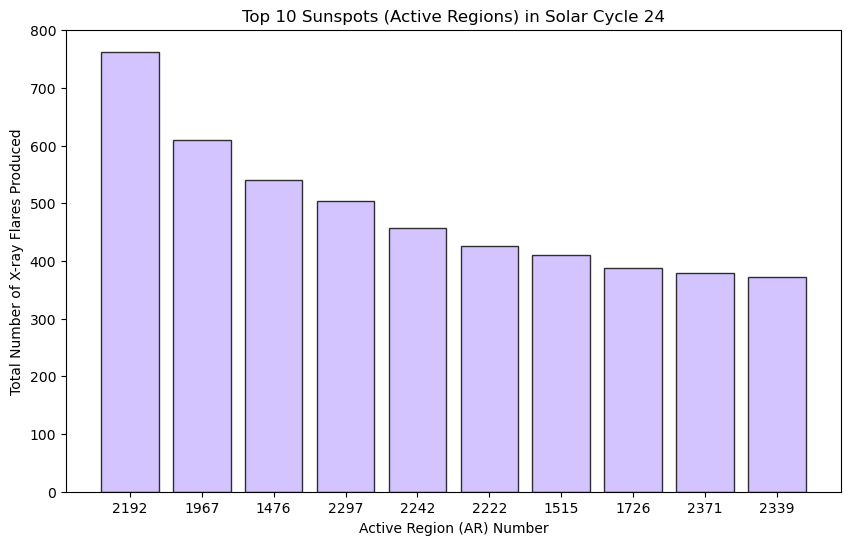

In [6]:

#  Set up the canvas
plt.figure(figsize=(10, 6))

# Convert the AR numbers to strings so Matplotlib treats them as labels, not math numbers
ar_labels = top_10_ars.index.astype(int).astype(str)
ar_counts = top_10_ars.values

#  Bar Chart
plt.bar(ar_labels, ar_counts, color='#c8b6ff', edgecolor='black', alpha=0.8)

#Top 10 Most Violent Sunspots (Active Regions) in Solar Cycle 24
plt.title("Top 10 Sunspots (Active Regions) in Solar Cycle 24")
plt.xlabel("Active Region (AR) Number")
plt.ylabel("Total Number of X-ray Flares Produced")

# plt.savefig('rhessiAR.png')
plt.show()

AR 2192 produces the most  flares, look up some papers on this

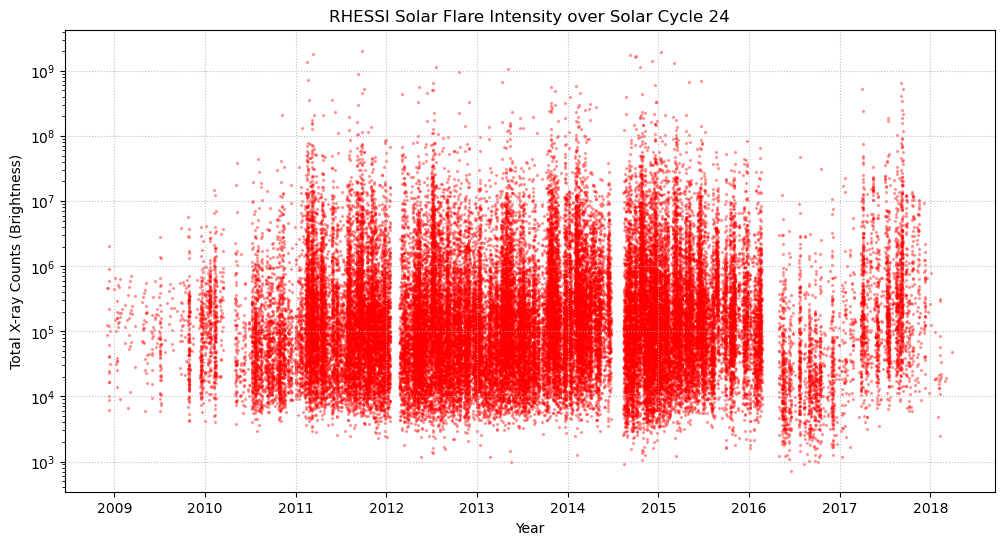

In [7]:
#  THE INTENSITY TIMELINE ---
# Translate NASA's raw seconds into real calendar dates
clean_df['Datetime'] = pd.to_datetime(clean_df['START_TIME'], origin='1979-01-01', unit='s')

# Build the scatter plot
plt.figure(figsize=(12, 6))

# Plot the Date vs the Total Counts
plt.scatter(clean_df['Datetime'], clean_df['TOTAL_COUNTS'], s=2, color='red', alpha=0.3)

# Format the graph
plt.title("RHESSI Solar Flare Intensity over Solar Cycle 24")
plt.xlabel("Year")
plt.ylabel("Total X-ray Counts (Brightness)")
plt.yscale('log') # We use a log scale because some flares are millions of times brighter than others!
plt.grid(True, linestyle=':', alpha=0.8)

# plt.savefig('rhessitimeline.png')
plt.show()

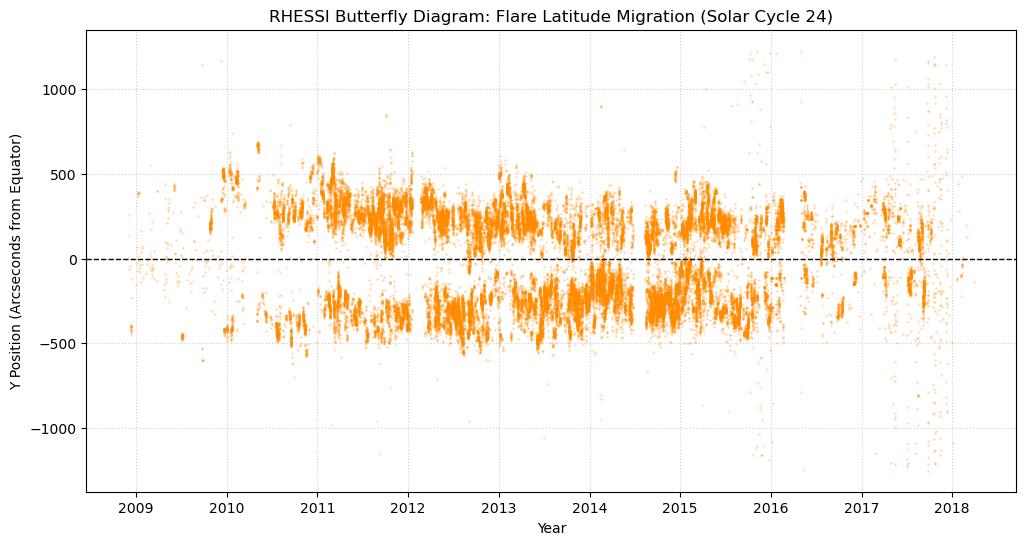

In [8]:
plt.figure(figsize=(12, 6))

# Plot the Date vs the Y-coordinate (Latitude)
plt.scatter(clean_df['Datetime'], clean_df['posi_y'], s=1, color='darkorange', alpha=0.2)

# Add a line across the equator (Y=0)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Format the graph
plt.title("RHESSI Butterfly Diagram: Flare Latitude Migration (Solar Cycle 24)")
plt.xlabel("Year")
plt.ylabel("Y Position (Arcseconds from Equator)")
plt.grid(True, linestyle=':', alpha=0.6)

# plt.savefig('butterfly.png')

plt.show()

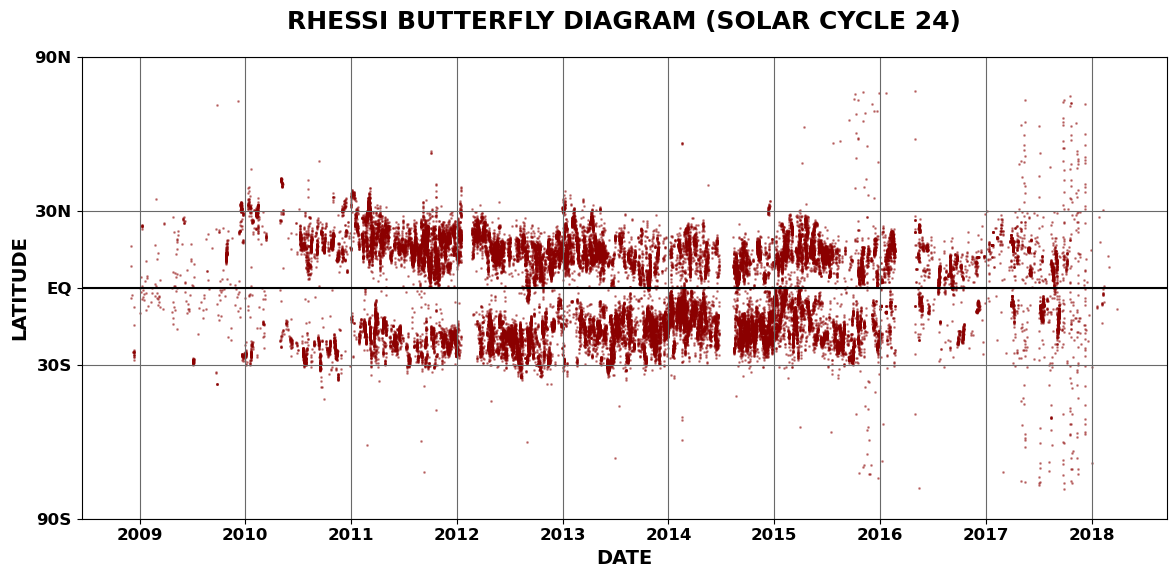

In [ ]:

plt.figure(figsize=(14, 6))

# Convert arcseconds to approximate latitude degrees (divide by 16)
latitude = clean_df['posi_y'] / 16

# Plot the Date vs the Latitude
plt.scatter(clean_df['Datetime'], latitude, s=1, color='darkred', alpha=0.4)

# Add a solid line across the equator (Y=0)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

#  Format with bold fonts :)
plt.title("RHESSI BUTTERFLY DIAGRAM (SOLAR CYCLE 24)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("DATE", fontsize=14, fontweight='bold')
plt.ylabel("LATITUDE", fontsize=14, fontweight='bold')

plt.grid(color='dimgrey', linestyle='-', linewidth=0.8)
plt.ylim(-90, 90)
plt.yticks([-90, -30, 0, 30, 90], ['90S', '30S', 'EQ', '30N', '90N'], fontweight='bold', fontsize=12)
plt.xticks(fontweight='bold', fontsize=12)

# plt.savefig('butterfly_2.0.png', dpi=300, bbox_inches='tight')

plt.show()

Generating SunPy Map Projection...


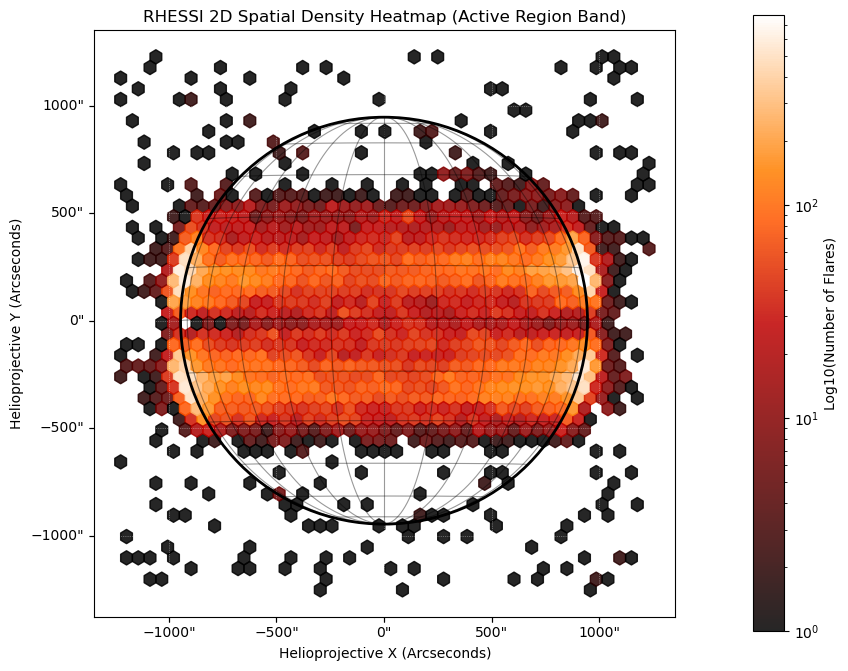

In [ ]:

print("Generating SunPy Map Projection...")

# Define the exact center of the Sun (0, 0 arcseconds)
center_coord = SkyCoord(0 * u.arcsec, 0 * u.arcsec, 
                        obstime='2014-06-01T00:00:00', 
                        observer='earth', 
                        frame='helioprojective')

# Create the "Blank" SunPy Map using that center point
empty_data = np.zeros((10, 10))
header = sunpy.map.make_fitswcs_header(
    empty_data,
    center_coord,
    reference_pixel=[5, 5] * u.pixel,
    scale=[200, 200] * u.arcsec / u.pixel
)
blank_map = sunpy.map.Map(empty_data, header)

# Set up the Canvas using the SunPy Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection=blank_map)

# Draw the  Solar Limb and Stonyhurst Grid
blank_map.plot(axes=ax, alpha=0) 
blank_map.draw_limb(axes=ax, color='black', linewidth=2)
blank_map.draw_grid(axes=ax, color='black', alpha=0.4, system='stonyhurst')

# Plot  DataFrame coordinates as a Heatmap

px= (clean_df['posi_x'] / 200)+5 # convert arcsecs to map pixels
py= (clean_df['posi_y'] / 200)+5

hb = ax.hexbin(
    px,
    py,  
    gridsize=45, 
    cmap='soholasco2', 
    bins='log',
    alpha=0.85
)

# 6. Formatting
cb = plt.colorbar(hb, label='Log10(Number of Flares)', pad=0.1)
plt.title("RHESSI 2D Spatial Density Heatmap (Active Region Band)")
plt.xlabel("Helioprojective X (Arcseconds)")
plt.ylabel("Helioprojective Y (Arcseconds)")

# plt.savefig('heatmap1.png')


plt.show()

Generating Final SunPy Map Projection...


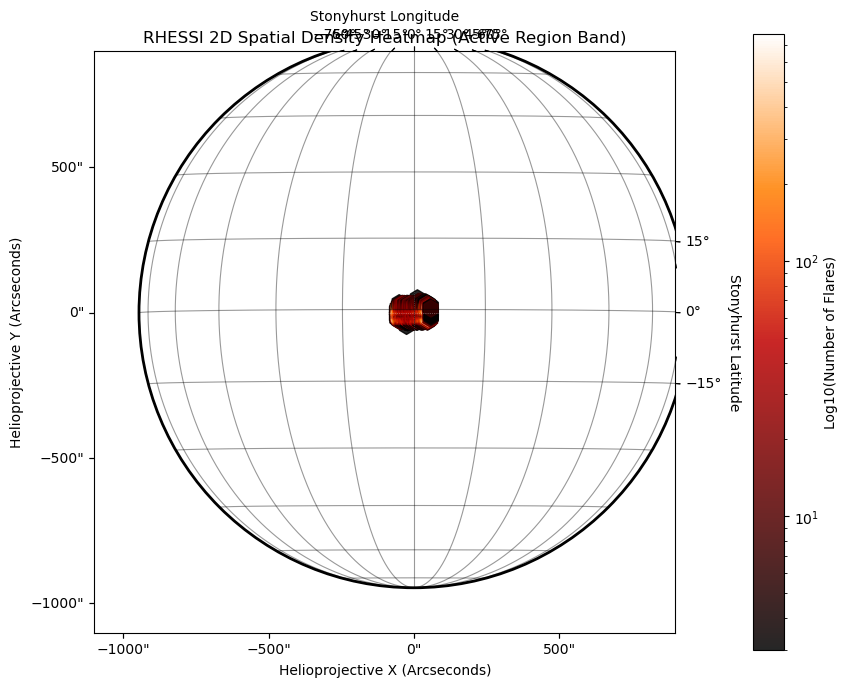

In [ ]:


print("Generating Final SunPy Map Projection...")

#  Define the exact center of the Sun
center_coord = SkyCoord(0 * u.arcsec, 0 * u.arcsec, 
                        obstime='2014-06-01T00:00:00', 
                        observer='earth', 
                        frame='helioprojective')

# Create the "Blank" SunPy Map
empty_data = np.zeros((10, 10))
header = sunpy.map.make_fitswcs_header(
    empty_data,
    center_coord,
    reference_pixel=[5, 5] * u.pixel,
    scale=[200, 200] * u.arcsec / u.pixel
)
blank_map = sunpy.map.Map(empty_data, header)

#Set up the Canvas using the SunPy Projection
fig = plt.figure(figsize=(10, 10)) 
ax = fig.add_subplot(projection=blank_map)

# Draw the  Solar Limb and Stonyhurst Grid
blank_map.plot(axes=ax, alpha=0) 
blank_map.draw_limb(axes=ax, color='black', linewidth=2)
blank_map.draw_grid(axes=ax, color='black', alpha=0.4, system='stonyhurst')

# Plot  DataFrame coordinates as a Heatmap
hb = ax.hexbin(
    clean_df['posi_x'] / 3600, # Convert to degrees
    clean_df['posi_y'] / 3600, #  Convert to degrees
    gridsize=45, 
    cmap='soholasco2', 
    bins='log',
    mincnt=3,                      # <-- Vaporizes the single-flare black space dust
    extent=[-0.3, 0.3, -0.3, 0.3], # <-- Locks a perfect square boundary in degrees
    alpha=0.85,
    transform=ax.get_transform('world')
)

# Formatting
cb = plt.colorbar(hb, label='Log10(Number of Flares)', pad=0.1, shrink=0.8)
plt.title("RHESSI 2D Spatial Density Heatmap (Active Region Band)")
plt.xlabel("Helioprojective X (Arcseconds)")
plt.ylabel("Helioprojective Y (Arcseconds)")

# plt.savefig('heatmap2.png')

plt.show()

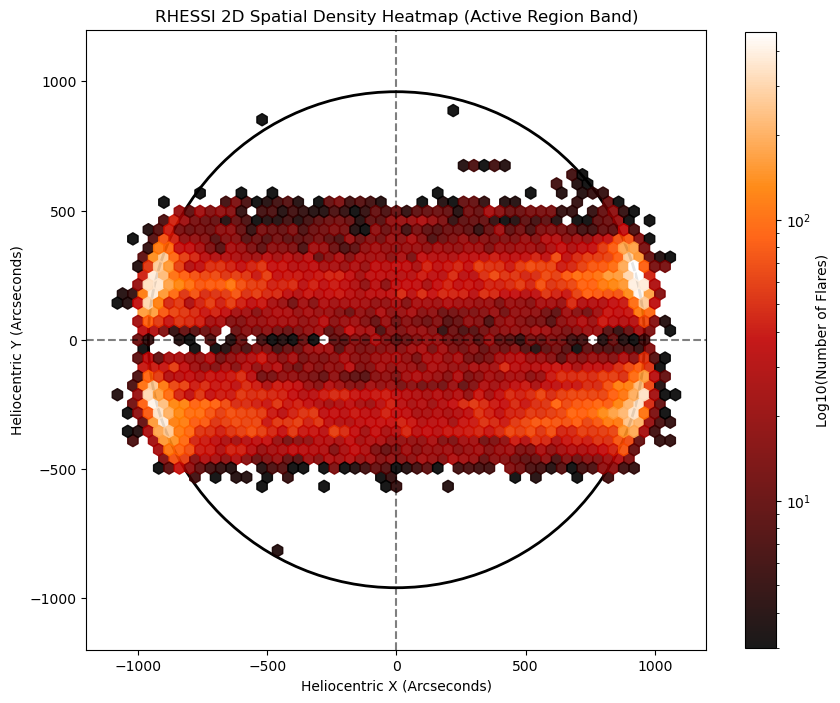

In [ ]:


fig, ax = plt.subplots(figsize=(10, 10))

#   draw the Sun (The physical radius of the Sun is ~960 arcseconds)
sun_limb = plt.Circle((0, 0), 960, color='black', fill=False, linewidth=2)
ax.add_patch(sun_limb)

#  Add  crosshairs for the Equator and Prime Meridian
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)

# Hexbin (no 3D warping)
hb = ax.hexbin(
    clean_df['posi_x'], 
    clean_df['posi_y'], 
    gridsize=55, 
    cmap='soholasco2', 
    bins='log',
    mincnt=3, # Vaporizes the space dust
    extent=[-1100, 1100, -1100, 1100], # Locks the geometric grid perfectly
    alpha=0.9
)

#  Format
ax.set_xlim(-1200, 1200)
ax.set_ylim(-1200, 1200)
ax.set_aspect('equal') # Prevents the "pill" stretching
    
cb = plt.colorbar(hb, label='Log10(Number of Flares)', shrink=0.8)
plt.title("RHESSI 2D Spatial Density Heatmap (Active Region Band)")
plt.xlabel("Heliocentric X (Arcseconds)")
plt.ylabel("Heliocentric Y (Arcseconds)")

# plt.savefig('heatmapfinal.png')
plt.show()